In [2]:
%cd D:\Uni\Master\Data Science\Project\Code_local\MOFA
#%pip install lifelines

D:\Uni\Master\Data Science\Project\Code_local\MOFA


In [2]:
print("Here we Analyse the explained variance of each factor towards each cohort (disease vs normal). this only works if you have the mofa_kidney_filtered_model.hdf5 file.")

import h5py
import numpy as np

outfile = "mofa_kidney_filtered_model.hdf5"
f = h5py.File(outfile, "r")

available_groups = ["Disease", "Normal"]
available_views = ["Methylation", "RNAseq","RPPA"]

for group in available_groups:
    total_matrix = f["variance_explained"]["r2_total"][group][:]
    factor_matrix = f["variance_explained"]["r2_per_factor"][group][:]

    print(f"\n=========================================\nDIAGNOSIS COHORT: {group.upper()}\n=========================================")
    
    for view_idx, view_name in enumerate(available_views):
        raw_total = total_matrix[view_idx]
        raw_factors = factor_matrix[view_idx, :]
        raw_factors = np.clip(raw_factors, 0, None)
        
        if raw_total <= 1.0 and np.max(raw_factors) <= 1.0:
            total_pct = raw_total * 100
            factors_pct = raw_factors * 100
        else:
            total_pct = raw_total
            factors_pct = raw_factors
        
        print(f"\n🔹 Modality: {view_name} (Total Variance Explained: {total_pct:.2f}%)")
        print(f"  {'Factor':12} | {'True Contribution to Modality':35}")
        print(f"  {'-'*12}-+-{'-'*35}")
        
        for factor_idx, final_r2 in enumerate(factors_pct):
            print(f"  Factor {factor_idx + 1:<4}     | {final_r2:.2f}%")



f.close()

Here we Analyse the explained variance of each factor towards each cohort (disease vs normal). this only works if you have the mofa_kidney_filtered_model.hdf5 file.

DIAGNOSIS COHORT: DISEASE

🔹 Modality: Methylation (Total Variance Explained: 38.53%)
  Factor       | True Contribution to Modality      
  -------------+------------------------------------
  Factor 1        | 3.45%
  Factor 2        | 4.81%
  Factor 3        | 2.86%
  Factor 4        | 4.70%
  Factor 5        | 1.39%
  Factor 6        | 3.47%
  Factor 7        | 1.14%
  Factor 8        | 1.05%
  Factor 9        | 1.93%
  Factor 10       | 0.73%
  Factor 11       | 0.25%
  Factor 12       | 0.41%
  Factor 13       | 1.05%
  Factor 14       | 0.00%
  Factor 15       | 0.00%

🔹 Modality: RNAseq (Total Variance Explained: 35.53%)
  Factor       | True Contribution to Modality      
  -------------+------------------------------------
  Factor 1        | 2.89%
  Factor 2        | 5.82%
  Factor 3        | 1.79%
  Factor 4   

In [3]:
print("This codeblock looks at the top 10 influencal features of each factor. Interesting is that the same feature can appear as a significant driver in multiple factors, sometimes positive and sometimes negative.")
import h5py
import numpy as np
import pandas as pd

outfile = "mofa_kidney_filtered_model.hdf5"
f = h5py.File(outfile, "r")

rna_features = [x.decode("utf-8") for x in f["features"]["RNAseq"][:]]
meth_features = [x.decode("utf-8") for x in f["features"]["Methylation"][:]]

weights_rna = f["expectations"]["W"]["RNAseq"][:].T
weights_meth = f["expectations"]["W"]["Methylation"][:].T

df_rna_weights = pd.DataFrame(weights_rna, index=rna_features)
df_meth_weights = pd.DataFrame(weights_meth, index=meth_features)


# For ease, we defined a function to iterate over all the factors to print out the top features.
def get_top_drivers(factor_number, top_n=10):
    f_idx = factor_number - 1

    print(
        f"\n======================================================\nTOP DRIVERS FOR FACTOR {factor_number}\n======================================================"
    )

    top_rna = df_rna_weights[f_idx].reindex(
        df_rna_weights[f_idx].abs().sort_values(ascending=False).index
    )
    print(f"\n🧬 Top {top_n} Driving Genes (RNAseq):")
    print(f"  {'Gene Name':20} | {'Weight Value':12}")
    print(f"  {'-'*20}-+-{'-'*12}")
    for gene, val in top_rna.head(top_n).items():
        print(f"  {gene:20} | {val:+.4f}")

    top_meth = df_meth_weights[f_idx].reindex(
        df_meth_weights[f_idx].abs().sort_values(ascending=False).index
    )
    print(f"\n🔹 Top {top_n} Driving Peaks (Methylation):")
    print(f"  {'Peak ID':20} | {'Weight Value':12}")
    print(f"  {'-'*20}-+-{'-'*12}")
    for peak, val in top_meth.head(top_n).items():
        print(f"  {peak:20} | {val:+.4f}")


get_top_drivers(factor_number=1, top_n=10)
get_top_drivers(factor_number=2, top_n=10)
get_top_drivers(factor_number=3, top_n=10)
get_top_drivers(factor_number=4, top_n=10)
get_top_drivers(factor_number=5, top_n=10)
get_top_drivers(factor_number=6, top_n=10)
get_top_drivers(factor_number=7, top_n=10)
get_top_drivers(factor_number=8, top_n=10)
get_top_drivers(factor_number=9, top_n=10)
get_top_drivers(factor_number=10, top_n=10)
f.close()

This codeblock looks at the top 10 influencal features of each factor. Interesting is that the same feature can appear as a significant driver in multiple factors, sometimes positive and sometimes negative.

TOP DRIVERS FOR FACTOR 1

🧬 Top 10 Driving Genes (RNAseq):
  Gene Name            | Weight Value
  ---------------------+-------------
  SLC22A6_rna          | +1.2392
  PRODH2_rna           | +1.1912
  SLC5A12_rna          | +1.1911
  SLC17A3_rna          | +1.1521
  ACSM2B_rna           | +1.1438
  SLC10A2_rna          | +1.1417
  SLC39A5_rna          | +1.1132
  SLC6A19_rna          | +1.1022
  NAT8_rna             | +1.0996
  SLC22A11_rna         | +1.0987

🔹 Top 10 Driving Peaks (Methylation):
  Peak ID              | Weight Value
  ---------------------+-------------
  cg10790704_meth      | -0.1111
  cg16233472_meth      | -0.1070
  cg04428071_meth      | -0.0969
  cg21201401_meth      | -0.0939
  cg14528751_meth      | -0.0936
  cg26530045_meth      | -0.0934
  cg14143304_m

In [4]:
print("Here we perform multiple statistical tests to see the relevant associations between the MOFA factors and the clinical/phenotype data.")
import os
import h5py
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, spearmanr
from lifelines import CoxPHFitter

model_filename = "mofa_kidney_filtered_model.hdf5"

if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Could not find '{model_filename}'")

print(f"Opening trained MOFA model from {model_filename} via h5py...")

factor_dfs = []

with h5py.File(model_filename, 'r') as f:
    groups_names = list(f['expectations/Z'].keys())
    
    for group_name in groups_names:
        factors = f[f'expectations/Z/{group_name}'][()].T
        raw_samples = f[f'samples/{group_name}'][()]
        samples = [s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in raw_samples]
        col_names = [f"Factor_{i+1}" for i in range(factors.shape[1])]
        g_df = pd.DataFrame(factors, index=samples, columns=col_names)
        factor_dfs.append(g_df)

mofa_factors_df = pd.concat(factor_dfs)
print(f"Extracted a matrix of {mofa_factors_df.shape[0]} samples across {mofa_factors_df.shape[1]} factors.")


print("Loading clinical and survival metadata tables...")
clin_df = pd.read_csv(os.path.join(os.getcwd(), "..", "TCGA-KIRC/KIRC_clinicalMatrix.txt"), sep="\t", index_col=0)
survival_df = pd.read_csv(os.path.join(os.getcwd(), "..", "TCGA-KIRC/KIRC_survival.txt"), sep="\t", index_col=0)

clinical_cols = ['age_at_initial_pathologic_diagnosis', 'gender', 'pathologic_stage', 'neoplasm_histologic_grade']
survival_cols = ['OS', 'OS.time']

clin_sub = clin_df[clinical_cols].copy()
survival_sub = survival_df[survival_cols].copy()

full_pheno_df = clin_sub.merge(survival_sub, left_index=True, right_index=True, how='inner')

print("We use the sample indices to find the matching samples.")
merged_data = mofa_factors_df.merge(full_pheno_df, left_index=True, right_index=True, how='inner')
print(f"Successfully matched complete clinical profiles for {len(merged_data)} samples.\n")



#RUN STATISTICAL ASSOCIATIONS
print("These Matrices are using the significance cutoff of p<0.05, meaning it wasn't corrected for multiple testing. Since we have 15 factors, the cutoff should be 0.05/15 for significant FWER values, meaning it would be 3.33e-03 values instead as a cutoff")

# 1. Spearman Correlation with Age
print("--- Spearman Correlation with Patient Age ---")
for col in mofa_factors_df.columns:
    valid = merged_data[[col, 'age_at_initial_pathologic_diagnosis']].dropna()
    if len(valid) > 10:
        rho, pval = spearmanr(valid[col], valid['age_at_initial_pathologic_diagnosis'])
        if pval < 0.05:
            print(f"  * {col} is significantly associated with Age! (Rho: {rho:.3f}, p-val: {pval:.4e})")

# 2. Kruskal-Wallis across Pathologic Tumor Stages
print("\n--- Kruskal-Wallis Test across Pathologic Stages ---")
for col in mofa_factors_df.columns:
    stage_sub = merged_data[[col, 'pathologic_stage']].dropna()
    stages = stage_sub['pathologic_stage'].unique()
    groups_data = [stage_sub[stage_sub['pathologic_stage'] == st][col].values for st in stages]
    groups_data = [g for g in groups_data if len(g) > 5]
    if len(groups_data) > 1:
        stat, pval = kruskal(*groups_data)
        if pval < 0.05:
            print(f"  * {col} significantly separates Tumor Stages! (p-val: {pval:.4e})")

# 3. Kruskal-Wallis across Histologic Grades
print("\n--- Kruskal-Wallis Test across Histologic Grades (G1-G4) ---")
for col in mofa_factors_df.columns:
    grade_sub = merged_data[[col, 'neoplasm_histologic_grade']].dropna()
    grades = grade_sub['neoplasm_histologic_grade'].unique()
    groups_data = [grade_sub[grade_sub['neoplasm_histologic_grade'] == gd][col].values for gd in grades]
    groups_data = [g for g in groups_data if len(g) > 5]
    if len(groups_data) > 1:
        stat, pval = kruskal(*groups_data)
        if pval < 0.05:
            print(f"  * {col} significantly separates Histologic Grades! (p-val: {pval:.4e})")

# 4. Cox Proportional Hazards Regression for Overall Survival (OS)
print("\n--- Cox Proportional Hazards Regression for Overall Survival ---")
print("We only keep samples that contain survival timelines. all censored samples are excluded. With more time, a proper handling of the censored data could be included.")

survival_fields = ['OS', 'OS.time']
factor_cols = list(mofa_factors_df.columns)

# Drop any row lacking complete survival timelines
cox_data = merged_data[factor_cols + survival_fields].dropna()

# Timeline entries have to be greater than zero to satisfy log calculations in the Cox solver
cox_data = cox_data[cox_data['OS.time'] > 0]

cph = CoxPHFitter()
cph.fit(cox_data, duration_col='OS.time', event_col='OS')
summary_df = cph.summary

# We filter out the factors that show strong predictive value (p < 0.05)
significant_survival_factors = summary_df[summary_df['p'] < 0.05]

if not significant_survival_factors.empty:
    for factor_name, row in significant_survival_factors.iterrows():
        print(f"  * {factor_name} is a SIGNIFICANT predictor of Overall Survival!")
        print(f"    -> Hazard Ratio (exp(coef)): {row['exp(coef)']:.3f} | p-value: {row['p']:.4e}")
else:
    print("  No individual factors met the statistical p < 0.05 threshold for Overall Survival.")
print("\n=== Full Cox Model Summary Matrix ===")
print(summary_df[['coef', 'exp(coef)', 'p', 'z']])

Here we perform multiple statistical tests to see the relevant associations between the MOFA factors and the clinical/phenotype data.
Opening trained MOFA model from mofa_kidney_filtered_model.hdf5 via h5py...
Extracted a matrix of 745 samples across 15 factors.
Loading clinical and survival metadata tables...
We use the sample indices to find the matching samples.
Successfully matched complete clinical profiles for 744 samples.

These Matrizes is using the significant cutoff of p<0.05, meaning it wasn't corrected for multiple testing. Since we have 15 factors, the cutoff should be 0.05/15 for significant FDR values, meaning it would be 3.33e-03 values instead as a cutoff
--- Spearman Correlation with Patient Age ---
  * Factor_3 is significantly associated with Age! (Rho: -0.129, p-val: 4.1055e-04)
  * Factor_5 is significantly associated with Age! (Rho: -0.157, p-val: 1.7617e-05)
  * Factor_6 is significantly associated with Age! (Rho: 0.121, p-val: 9.6105e-04)

--- Kruskal-Wallis Te

In [5]:
print("This code extracts the top 500 Features per factor for annotation (Rmd script) and ML input. ignore if you already have the file data/mofa_top_500_features_per_factor.csv")
import os
import h5py
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


print("\n--- Beginning Top 500 Feature Extraction per Factor ---")
output_csv = "data/mofa_top_500_features_per_factor.csv"
all_exported_features = []
model_filename="mofa_kidney_filtered_model.hdf5"
with h5py.File(model_filename, 'r') as f:
    views_names = list(f['expectations/W'].keys())
    
    for view_name in views_names:
        W_matrix = f[f'expectations/W/{view_name}'][()]
        raw_features = f[f'features/{view_name}'][()]
        features = [feat.decode('utf-8') if isinstance(feat, bytes) else str(feat) for feat in raw_features]
        
        num_factors = W_matrix.shape[0]
        
        for factor_idx in range(num_factors):
            factor_weights = W_matrix[factor_idx, :]
            abs_weights = np.abs(factor_weights)
            top_100_indices = np.argsort(abs_weights)[-500:][::-1]
            
            for rank, idx in enumerate(top_100_indices):
                all_exported_features.append({
                    "Factor": f"Factor_{factor_idx + 1}",
                    "View": view_name,
                    "Feature_Name": features[idx],
                    "Raw_Weight": factor_weights[idx],
                    "Absolute_Weight": abs_weights[idx],
                    "Rank": rank + 1
                })

export_df = pd.DataFrame(all_exported_features)
export_df.to_csv(output_csv, index=False)
print(f"Successfully generated and saved registry file to: {output_csv}")

This code extracts the top 500 Features per factor for annotation (Rmd script) and ML input. ignore if you already have the file data/mofa_top_500_features_per_factor.csv

--- Beginning Top 500 Feature Extraction per Factor ---
Successfully generated and saved registry file to: data/mofa_top_500_features_per_factor.csv


In [6]:
print("This script exports ALL feature weights. This is later used in R along the top 500 features, to annotate the significant pathways.")
import os
import h5py
import pandas as pd

# =====================================================================
# CONFIGURATION
# =====================================================================
model_filename = "mofa_kidney_filtered_model.hdf5"
output_csv = "data/feature_weights.csv"

if not os.path.exists(model_filename):
    raise FileNotFoundError(
        f"Could not find '{model_filename}'. Please ensure it is in your "
        "working directory or update the model_filename path variable."
    )

print(f"Extracting all feature weights from {model_filename}...")
all_weights_records = []

# Open and parse the HDF5 archive natively
with h5py.File(model_filename, 'r') as f:
    # 1. Discover all views/modalities in the model (e.g., RNAseq, Methylation, etc.)
    views_names = list(f['expectations/W'].keys())
    
    for view_name in views_names:
        # 2. Extract the weight matrix W for the current view
        # MOFA stores W inside HDF5 as shape: (factors, features)
        W_matrix = f[f'expectations/W/{view_name}'][()]
        
        # 3. Extract the feature names vector and safely decode from binary HDF5 bytes
        raw_features = f[f'features/{view_name}'][()]
        features = [feat.decode('utf-8') if isinstance(feat, bytes) else str(feat) for feat in raw_features]
        
        num_factors = W_matrix.shape[0]
        
        # 4. Loop through every factor and feature to build the rows
        for factor_idx in range(num_factors):
            factor_name = f"Factor_{factor_idx + 1}"
            
            for feat_idx, feature_name in enumerate(features):
                weight_val = W_matrix[factor_idx, feat_idx]
                
                # Append a record matching the column names your R script checks
                all_weights_records.append({
                    "Factor": factor_name,
                    "View": view_name,
                    "Feature_Name": feature_name,
                    "Weight": weight_val
                })

weights_df = pd.DataFrame(all_weights_records)

weights_df.to_csv(output_csv, index=False)

print("\n=== Export Successful ===")
print(f"Saved complete weights registry to: {output_csv}")
print(f"Total entries processed: {len(weights_df)}")

available_views = weights_df["View"].unique()
print(f"\nDetected views inside your model: {available_views}")

matching_views = [v for v in available_views if v in ["RNA", "RNAseq", "RNA-Seq", "Expression"]]
if matching_views:
    print(f"-> SUCCESS: Found matching RNA views for your R script: {matching_views}")
else:
    print(f"-> WARNING: None of your views match the R script filters. Your views are named {available_views}.")

This script exports ALL feature weights. This is later used in R along the top 500 features, to annotate the significant pathways.
Extracting all feature weights from mofa_kidney_filtered_model.hdf5...

=== Export Successful ===
Saved complete weights registry to: data/feature_weights.csv
Total entries processed: 6176190

Detected views inside your model: ['Methylation' 'RNAseq' 'RPPA']
-> SUCCESS: Found matching RNA views for your R script: ['RNAseq']


In [7]:
print("This codeblock generates plots of the variance explanation of the cohorts by the factors per view.")
import os
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_filename = "mofa_kidney_filtered_model.hdf5"
available_groups = ["Disease", "Normal"]
available_views = ["Methylation", "RNAseq", "RPPA"]
output_directory = "mofa_plots"

os.makedirs(output_directory, exist_ok=True)

if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Could not find trained MOFA model snapshot: '{model_filename}'")

sns.set_theme(style="whitegrid", context="talk")

#PLOT INDEPENDENTLY PER GROUP & MODALITY
with h5py.File(model_filename, "r") as f:
    for group in available_groups:
        total_matrix = f["variance_explained"]["r2_total"][group][:]
        factor_matrix = f["variance_explained"]["r2_per_factor"][group][:]

        for view_idx, view_name in enumerate(available_views):
            raw_total = total_matrix[view_idx]
            raw_factors = factor_matrix[view_idx, :]
            raw_factors = np.clip(raw_factors, 0, None)
            
            if raw_total <= 1.0 and np.max(raw_factors) <= 1.0:
                total_pct = raw_total * 100
                factors_pct = raw_factors * 100
            else:
                total_pct = raw_total
                factors_pct = raw_factors

            current_records = []
            for factor_idx, final_r2 in enumerate(factors_pct):
                current_records.append({
                    "Factor": f"Factor {factor_idx + 1}",
                    "Variance_Explained": final_r2
                })
            df_plot = pd.DataFrame(current_records)
            
            print("start plotting...")
            plt.figure(figsize=(10, 5))
            
            ax = sns.barplot(
                data=df_plot,
                x="Factor",
                y="Variance_Explained",
                hue="Factor",
                palette="viridis",
                dodge=False,
                legend=False
            )

            plt.ylabel("Variance Explained (%)", fontweight="bold", fontsize=14)
            plt.xlabel("")
            plt.title(
                f"Cohort: {group.upper()} | Modality: {view_name}\n"
                f"(Total Modality Variance Explained: {total_pct:.2f}%)", 
                fontsize=15, 
                fontweight="bold", 
                pad=15
            )
            
            plt.xticks(rotation=45, ha='right', fontsize=11)
            plt.yticks(fontsize=11)

            for p in ax.patches:
                height = p.get_height()
                if height > 0.1:
                    ax.annotate(
                        f'{height:.2f}%', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', 
                        va='center', 
                        xytext=(0, 6), 
                        textcoords='offset points', 
                        fontsize=10, 
                        fontweight="bold"
                    )

            plt.tight_layout()
            safe_filename = f"mofa_variance_{group.lower()}_{view_name.lower()}.png"
            full_export_path = os.path.join(output_directory, safe_filename)
            
            plt.savefig(full_export_path, dpi=300, bbox_inches='tight')
            plt.close()
            
            print(f"-> Generated file: {full_export_path}")

print(f"\nAll Plots saved to: '{output_directory}/'")

This codeblock generates plots of the variance explanation of the cohorts by the factors per view.
start plotting...
-> Generated file: mofa_plots\mofa_variance_disease_methylation.png
start plotting...
-> Generated file: mofa_plots\mofa_variance_disease_rnaseq.png
start plotting...
-> Generated file: mofa_plots\mofa_variance_disease_rppa.png
start plotting...
-> Generated file: mofa_plots\mofa_variance_normal_methylation.png
start plotting...
-> Generated file: mofa_plots\mofa_variance_normal_rnaseq.png
start plotting...
-> Generated file: mofa_plots\mofa_variance_normal_rppa.png

=== Execution Complete! All plots saved inside the directory: 'mofa_plots/' ===


This codeblock calculates and plots the significanct associations of Phenotype and clinical data to the latent factors from MOFA. The results are the same as the table significance output further up.
Opening trained MOFA model from mofa_kidney_filtered_model.hdf5 via h5py...
Extracted a matrix of 745 samples across 15 factors.
Loading clinical and survival metadata tables...
Successfully matched complete clinical profiles for 744 samples.

Running statistical evaluations and gathering p-values...
Generating scaled significance barplot...


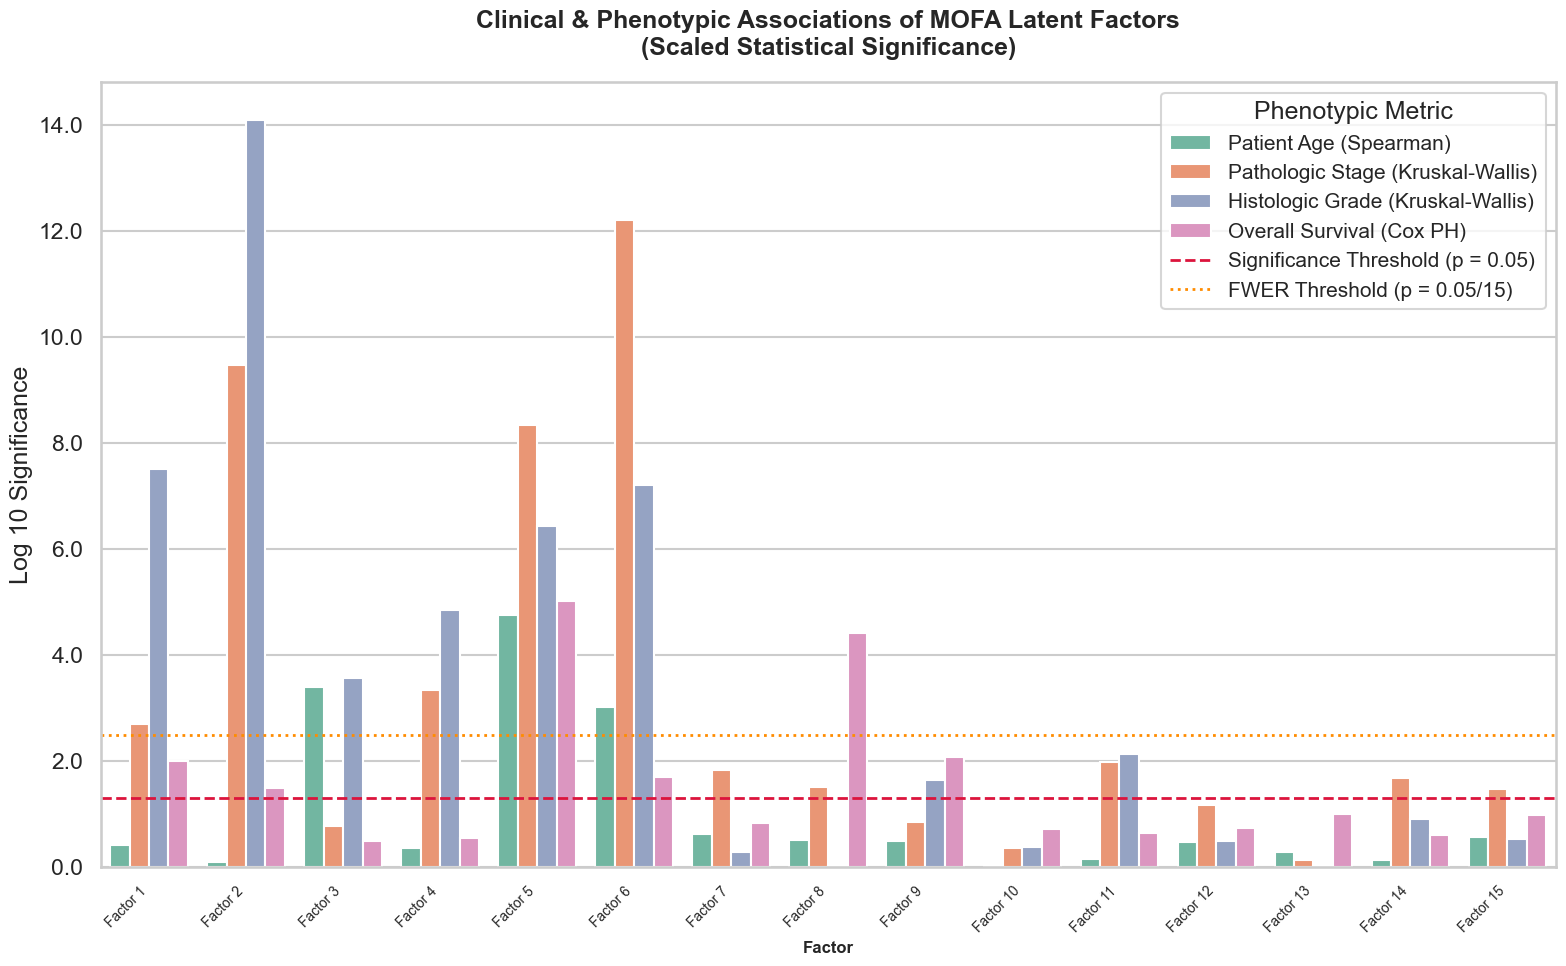

Association plot successfully saved to: mofa_plots\mofa_factors_phenotype_associations.png


In [3]:
print("This codeblock calculates and plots the significanct associations of Phenotype and clinical data to the latent factors from MOFA. The results are the same as the table significance output further up.")
import os
import h5py
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, spearmanr
from lifelines import CoxPHFitter

model_filename = "mofa_kidney_filtered_model.hdf5"

if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Could not find '{model_filename}'")

print(f"Opening trained MOFA model from {model_filename} via h5py...")

factor_dfs = []

with h5py.File(model_filename, 'r') as f:
    groups_names = list(f['expectations/Z'].keys())
    
    for group_name in groups_names:
        factors = f[f'expectations/Z/{group_name}'][()].T
        raw_samples = f[f'samples/{group_name}'][()]
        
        samples = [s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in raw_samples]
        
        col_names = [f"Factor_{i+1}" for i in range(factors.shape[1])]
        g_df = pd.DataFrame(factors, index=samples, columns=col_names)
        factor_dfs.append(g_df)

mofa_factors_df = pd.concat(factor_dfs)
print(f"Extracted a matrix of {mofa_factors_df.shape[0]} samples across {mofa_factors_df.shape[1]} factors.")


print("Loading clinical and survival metadata tables...")
clin_df = pd.read_csv(os.path.join(os.getcwd(), "..", "TCGA-KIRC/KIRC_clinicalMatrix.txt"), sep="\t", index_col=0)
survival_df = pd.read_csv(os.path.join(os.getcwd(), "..", "TCGA-KIRC/KIRC_survival.txt"), sep="\t", index_col=0)

clinical_cols = ['age_at_initial_pathologic_diagnosis', 'gender', 'pathologic_stage', 'neoplasm_histologic_grade']
survival_cols = ['OS', 'OS.time']

clin_sub = clin_df[clinical_cols].copy()
survival_sub = survival_df[survival_cols].copy()

full_pheno_df = clin_sub.merge(survival_sub, left_index=True, right_index=True, how='inner')

#INTERSECT MODEL FACTORS WITH PHENOTYPIC LABELS

merged_data = mofa_factors_df.merge(full_pheno_df, left_index=True, right_index=True, how='inner')
print(f"Successfully matched complete clinical profiles for {len(merged_data)} samples.\n")

#RUN STATISTICAL ASSOCIATIONS & COLLECT P-VALUES
print("Running statistical evaluations and gathering p-values...")
association_records = []

# Fit Cox Proportional Hazards for Overall Survival once to get p-values for all factors
factor_cols = list(mofa_factors_df.columns)
cox_data = merged_data[factor_cols + survival_cols].dropna()
cox_data = cox_data[cox_data['OS.time'] > 0]
cph = CoxPHFitter()
cph.fit(cox_data, duration_col='OS.time', event_col='OS')
cox_summary = cph.summary

for col in factor_cols:
    # 1. Age (Spearman)
    valid_age = merged_data[[col, 'age_at_initial_pathologic_diagnosis']].dropna()
    if len(valid_age) > 10:
        _, p_age = spearmanr(valid_age[col], valid_age['age_at_initial_pathologic_diagnosis'])
    else:
        p_age = 1.0
        
    # 2. Tumor Stage (Kruskal-Wallis)
    stage_sub = merged_data[[col, 'pathologic_stage']].dropna()
    stages = stage_sub['pathologic_stage'].unique()
    stage_groups = [stage_sub[stage_sub['pathologic_stage'] == st][col].values for st in stages]
    stage_groups = [g for g in stage_groups if len(g) > 5]
    p_stage = kruskal(*stage_groups)[1] if len(stage_groups) > 1 else 1.0
    
    # 3. Histologic Grade (Kruskal-Wallis)
    grade_sub = merged_data[[col, 'neoplasm_histologic_grade']].dropna()
    grades = grade_sub['neoplasm_histologic_grade'].unique()
    grade_groups = [grade_sub[grade_sub['neoplasm_histologic_grade'] == gd][col].values for gd in grades]
    grade_groups = [g for g in grade_groups if len(g) > 5]
    p_grade = kruskal(*grade_groups)[1] if len(grade_groups) > 1 else 1.0
    
    # 4. Overall Survival (Cox PH)
    p_survival = cox_summary.loc[col, 'p'] if col in cox_summary.index else 1.0
    
    for test_name, p_val in [
        ("Patient Age (Spearman)", p_age),
        ("Pathologic Stage (Kruskal-Wallis)", p_stage),
        ("Histologic Grade (Kruskal-Wallis)", p_grade),
        ("Overall Survival (Cox PH)", p_survival)
    ]:
        p_val_clean = max(p_val, 1e-300)
        minus_log_p = -np.log10(p_val_clean)
        
        association_records.append({
            "Factor": col.replace("_", " "),
            "Metadata": test_name,
            "p_value": p_val,
            "Log 10 Significance": minus_log_p
        })

df_assoc = pd.DataFrame(association_records)

print("Generating scaled significance barplot...")
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(16, 10))

ax = sns.barplot(
    data=df_assoc,
    x="Factor",
    y="Log 10 Significance",
    hue="Metadata",
    palette="Set2"
)
#P-value line
sig_threshold = -np.log10(0.05)
plt.axhline(
    y=sig_threshold, 
    color="crimson", 
    linestyle="--", 
    linewidth=2, 
    label="Significance Threshold (p = 0.05)"
)
#FWER-line
fdr_p = 0.05 / 15
fdr_threshold = -np.log10(fdr_p)
plt.axhline(
    y=fdr_threshold,
    color="darkorange",
    linestyle=":",
    linewidth=2,
    label="FWER Threshold (p = 0.05/15)"
)
plt.xlabel("Factor", fontweight="bold", fontsize=12)

plt.title(
    "Clinical & Phenotypic Associations of MOFA Latent Factors\n"
    "(Scaled Statistical Significance)", 
    fontsize=18, 
    fontweight="bold", 
    pad=20
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10
)

from matplotlib import ticker

def log10_tick_formatter(x, _):
    return f"{x:.1f}"

ax.yaxis.set_major_formatter(ticker.FuncFormatter(log10_tick_formatter))

ax.legend(
    title="Phenotypic Metric",
    loc="upper right",
    bbox_to_anchor=(1, 1),
    frameon=True,
    fontsize=15,
    title_fontsize=18
)

plt.tight_layout()

output_filepath = "mofa_plots\mofa_factors_phenotype_associations.png"
plt.savefig(output_filepath, dpi=300, bbox_inches='tight')
plt.show()

print(f"Association plot successfully saved to: {output_filepath}")

In [9]:
print("This block compares the normal vs disease cohorts and gives the difference back")

import os
import h5py
import numpy as np
import pandas as pd

model_filename = "mofa_kidney_filtered_model.hdf5"
available_groups = ["Normal", "Disease"]  
available_views = ["Methylation", "RNAseq", "RPPA"]

if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Could not find trained MOFA model snapshot: '{model_filename}'")

comparison_records = []


with h5py.File(model_filename, "r") as f:
    
    normal_total = f["variance_explained"]["r2_total"]["Normal"][:]
    normal_factors = f["variance_explained"]["r2_per_factor"]["Normal"][:]
    
    disease_total = f["variance_explained"]["r2_total"]["Disease"][:]
    disease_factors = f["variance_explained"]["r2_per_factor"]["Disease"][:]
    
    for view_idx, view_name in enumerate(available_views):
        # Clip negative noise artifacts
        norm_f_raw = np.clip(normal_factors[view_idx, :], 0, None)
        dis_f_raw = np.clip(disease_factors[view_idx, :], 0, None)
        
        if normal_total[view_idx] <= 1.0 and np.max(norm_f_raw) <= 1.0:
            norm_factors_pct = norm_f_raw * 100
        else:
            norm_factors_pct = norm_f_raw

        if disease_total[view_idx] <= 1.0 and np.max(dis_f_raw) <= 1.0:
            dis_factors_pct = dis_f_raw * 100
        else:
            dis_factors_pct = dis_f_raw

        for factor_idx in range(len(norm_factors_pct)):
            val_normal = norm_factors_pct[factor_idx]
            val_disease = dis_factors_pct[factor_idx]
       
        
            abs_diff = val_disease - val_normal
            fold_change = (val_disease / val_normal) if val_normal > 0.01 else np.nan
            
            comparison_records.append({
                "Modality": view_name,
                "Factor": f"Factor {factor_idx + 1}",
                "R2_Normal (%)": round(val_normal, 4),
                "R2_Disease (%)": round(val_disease, 4),
                "Variance_Difference (Disease - Normal)": round(abs_diff, 4),
                "Fold_Change (Disease / Normal)": round(fold_change, 2) if not np.isnan(fold_change) else "N/A"
            })


df_comparison = pd.DataFrame(comparison_records)

#Here I sort by the most discrepant factors to highlight cohort-specific drivers
df_comparison = df_comparison.sort_values(
    by="Variance_Difference (Disease - Normal)", 
    key=abs, 
    ascending=False
)

output_file = "data/mofa_cohort_variance_comparison.csv"
df_comparison.to_csv(output_file, index=False)

print(f"=== EXTRACTION COMPLETE ===")
print(f"Saved cohort variance comparison table to: '{output_file}'\n")
print(df_comparison.head(10).to_string(index=False))

This block compares the normal vs disease cohorts and gives the difference back
=== EXTRACTION COMPLETE ===
Saved cohort variance comparison table to: 'data/mofa_cohort_variance_comparison.csv'

   Modality   Factor  R2_Normal (%)  R2_Disease (%)  Variance_Difference (Disease - Normal) Fold_Change (Disease / Normal)
Methylation Factor 1        28.1733          3.4485                                -24.7247                           0.12
     RNAseq Factor 1        21.1190          2.8916                                -18.2274                           0.14
Methylation Factor 3         9.2456          2.8578                                 -6.3878                           0.31
     RNAseq Factor 7         0.4950          6.2924                                  5.7974                          12.71
     RNAseq Factor 2        11.5165          5.8151                                 -5.7014                            0.5
     RNAseq Factor 5         1.9766          7.0522                

Just another plot to show the different variance explanation of disease vs normal of the different factors


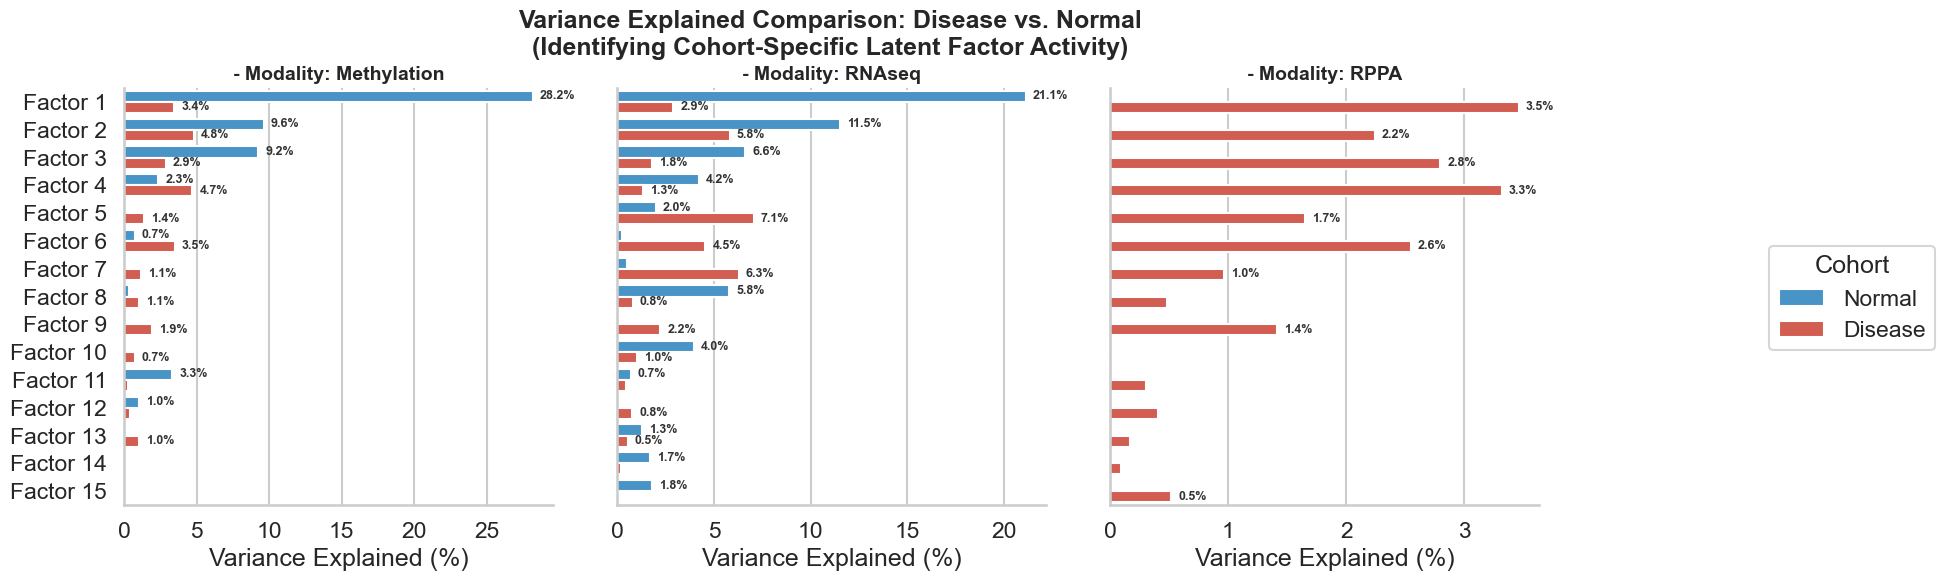

Comparison plot successfully saved to: mofa_plots/mofa_cohort_variance_comparison.png


In [10]:
print("Just another plot to show the different variance explanation of disease vs normal of the different factors")
import os
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


model_filename = "mofa_kidney_filtered_model.hdf5"
available_groups = ["Normal", "Disease"]
available_views = ["Methylation", "RNAseq", "RPPA"]
output_image = "mofa_plots/mofa_cohort_variance_comparison.png"

if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Could not find trained MOFA model snapshot: '{model_filename}'")

plot_records = []

with h5py.File(model_filename, "r") as f:
    for group in available_groups:
        total_matrix = f["variance_explained"]["r2_total"][group][:]
        factor_matrix = f["variance_explained"]["r2_per_factor"][group][:]

        for view_idx, view_name in enumerate(available_views):
            raw_total = total_matrix[view_idx]
            raw_factors = factor_matrix[view_idx, :]
            raw_factors = np.clip(raw_factors, 0, None)
            
            
            if raw_total <= 1.0 and np.max(raw_factors) <= 1.0:
                factors_pct = raw_factors * 100
            else:
                factors_pct = raw_factors

            for factor_idx, final_r2 in enumerate(factors_pct):
                plot_records.append({
                    "Group": group,
                    "Modality": view_name,
                    "Factor": f"Factor {factor_idx + 1}",
                    "Variance_Explained": final_r2
                })


df_plot = pd.DataFrame(plot_records)
sns.set_theme(style="whitegrid", context="talk")


g = sns.FacetGrid(
    df_plot, 
    col="Modality", 
    col_wrap=3, 
    sharex=False, 
    sharey=True, 
    height=6, 
    aspect=0.9
)


g.map_dataframe(
    sns.barplot, 
    y="Factor", 
    x="Variance_Explained", 
    hue="Group", 
    palette={"Normal": "#3498db", "Disease": "#e74c3c"},
    orient="h"
)


g.set_axis_labels("Variance Explained (%)", "")
g.set_titles(template="- Modality: {col_name}", size=14, weight="bold")
g.add_legend(title="Cohort", bbox_to_anchor=(1.02, 0.5), loc="center left", frameon=True)

for ax in g.axes.flatten():
    for p in ax.patches:
        width = p.get_width()
        if width > 0.5:  # > 0.5% variance
            ax.annotate(
                f'{width:.1f}%', 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points', 
                fontsize=9, 
                fontweight="bold",
                color="#333333"
            )

plt.subplots_adjust(top=0.85, wspace=0.15)
g.fig.suptitle(
    "Variance Explained Comparison: Disease vs. Normal\n"
    "(Identifying Cohort-Specific Latent Factor Activity)", 
    fontsize=18, 
    fontweight='bold', 
    y=0.98
)

plt.savefig(output_image, dpi=300, bbox_inches='tight')
plt.show()

print(f"Comparison plot successfully saved to: {output_image}")

In [11]:
print("This code was used  to extract the Z-matrix for ML. I'm not too sure wheter that matrix was used in the final result, but i put this here since at one point it was used.")
import os
import h5py
import pandas as pd

model_filename = "mofa_kidney_filtered_model.hdf5"
output_csv = "data/mofa_sample_factor_matrix.csv"

if not os.path.exists(model_filename):
    raise FileNotFoundError(
        f"Could not find '{model_filename}' in your current working directory. "
        "Please update the filename or path if it is stored elsewhere."
    )

print(f"Opening trained MOFA model from {model_filename}...")

factor_dfs = []

with h5py.File(model_filename, 'r') as f:
    groups_names = list(f['expectations/Z'].keys())
    
    for group_name in groups_names:
        factors = f[f'expectations/Z/{group_name}'][()].T
        raw_samples = f[f'samples/{group_name}'][()]
        samples = [s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in raw_samples]
        col_names = [f"Factor_{i+1}" for i in range(factors.shape[1])]
        g_df = pd.DataFrame(factors, index=samples, columns=col_names)
        factor_dfs.append(g_df)

mofa_factors_df = pd.concat(factor_dfs)
mofa_factors_df.index.name = "Sample_ID"
mofa_factors_df.to_csv(output_csv)

print("\n=== Export Complete ===")
print(f"Saved dataset to: {output_csv}")
print(f"Total rows (Samples):  {mofa_factors_df.shape[0]}")
print(f"Total columns (Factors): {mofa_factors_df.shape[1]}")
print("\nPreview of the exported table:")
print(mofa_factors_df.head())

This code was used  to extract the Z-matrix for ML. I'm not too sure wheter that matrix was used in the final result, but i put this here since at one point it was used.
Opening trained MOFA model from mofa_kidney_filtered_model.hdf5...

=== Export Complete ===
Saved dataset to: data/mofa_sample_factor_matrix.csv
Total rows (Samples):  745
Total columns (Factors): 15

Preview of the exported table:
                 Factor_1  Factor_2  Factor_3  Factor_4  Factor_5  Factor_6  \
Sample_ID                                                                     
TCGA-T7-A92I-01 -0.771584 -0.345181  1.556812 -4.166764 -0.596485 -3.421830   
TCGA-CW-5590-01  0.302790 -0.065414 -0.595936  1.442542 -0.930773  2.034855   
TCGA-BP-5168-01  1.642579  2.370443 -1.531982  0.444916  0.146063 -1.205397   
TCGA-CJ-4899-01 -0.153688  0.133519  1.314308  3.556804  0.780966 -1.449429   
TCGA-BP-5174-01  1.110458  1.052796 -0.725136  0.034965  0.342585 -2.043605   

                 Factor_7  Factor_8  Factor_